In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cortex
import utils 
import torch

from himalaya.ridge import GroupRidgeCV
from himalaya.kernel_ridge import MultipleKernelRidgeCV, linear_kernel
from himalaya.kernel_ridge import solve_multiple_kernel_ridge_random_search
from himalaya.backend import set_backend
from sklearn.model_selection import LeaveOneGroupOut
from typing import Dict, List, Union
from scipy.stats import zscore, pearsonr, norm
from scipy.interpolate import interp1d
from transformers import BertTokenizer, BertModel, GPT2Tokenizer, GPT2LMHeadModel, GPT2Model
from data_sequence import DataSequence
from textgrid_utils import load_generic_trfiles, load_textgrid_transcripts

In [3]:
# ----------------------------
# Configuration
# ----------------------------
backend = set_backend("torch_cuda")
fdir = os.path.abspath("./")
subject = "07"
modality = "listening"  # "listening" or "reading"
semantic_key = "english1000"
# Dataset-specific available keys
nuis_reading  = ["letters", "numletters", "word_length_std", "numwords", "pauses"]
nuis_listening = ["phonemes", "numphonemes", "numwords", "pauses"]

delays = list(range(5))    # 0..9 (approx 0–18 s for TR~2s)
alphas = np.logspace(1, 8, 12)  # regularization grid

In [4]:
# ----------------------------
# IO helpers
# ----------------------------
def load_responses_train(fdir, subject, modality):
    fname_trn = os.path.join(fdir, "responses", f"subject{subject}_{modality}_fmri_data_trn.hdf")
    return utils.load_data(fname_trn)  # dict: story -> (T x V)

def load_responses_val(fdir, subject, modality):
    fname_val = os.path.join(fdir, "responses", f"subject{subject}_{modality}_fmri_data_val.hdf")
    return utils.load_data(fname_val)  # dict with "story_11"

def load_features_train(fdir):
    fname_trnF = os.path.join(fdir, "features", "features_trn_NEW.hdf")
    return utils.load_data(fname_trnF)  # dict: story -> dict(space -> T x P)

def load_features_val(fdir):
    fname_valF = os.path.join(fdir, "features", "features_val_NEW.hdf")
    return utils.load_data(fname_valF)  # dict: "story_11" -> dict(space -> T x P)

In [5]:
# ----------------------------
# Build matrices with exact alignment across stories
# ----------------------------
def build_story_list(F_trn, required_keys):
    stories = sorted(F_trn.keys())
    # Keep only stories that contain all required keys
    ok = [s for s in stories if set(required_keys).issubset(F_trn[s].keys())]
    if not ok:
        raise ValueError("No story contains all required feature keys.")
    return ok

def stack_features(F, stories, keys, standardize=True):
    blocks = {}
    for s in stories:
        X = np.hstack([np.asarray(F[s][k]) for k in keys])
        if standardize:
            X = (X - X.mean(0)) / (X.std(0) + 1e-8)
        blocks[s] = X
    return blocks

def stack_responses(R, stories, trim, standardize=True):
    Ys, lens = [], []
    for s in stories:
        Y = np.asarray(R[s][trim:])
        if standardize:
            Y = (Y - Y.mean(0)) / (Y.std(0) + 1e-8)
        Ys.append(np.nan_to_num(Y))
        lens.append(Y.shape[0])
    return np.vstack(Ys), np.array(lens)

def delay_and_stack(X, stories, delays):
    blocks = []
    for s in stories:
        X_d = make_delayed(X[s], delays)
        blocks.append(X_d)
    return np.vstack(blocks)


def align_Y_after_delays(Y_blocks, lens, lens_d):
    # Drop the first (lens - lens_d) rows per story to align with X after delays
    Ys = []
    cursor = 0
    for L, Ld in zip(lens, lens_d):
        Y_block = Y_blocks[cursor:cursor+L, :]
        drop = L - Ld
        Ys.append(Y_block[drop:, :])
        cursor += L
    return np.vstack(Ys)

def build_feature_groups(F_one_story, keys, n_delays):
    # Produce a group index per column in the delayed design
    group_idx_raw = []
    for gi, k in enumerate(keys):
        group_idx_raw.append(np.full(F_one_story[k].shape[1], gi, dtype=int))
    group_idx_raw = np.hstack(group_idx_raw)
    groups_delayed = np.repeat(group_idx_raw, n_delays)
    return groups_delayed

def make_story_ids(lens_d):
    # Sample-level group labels for LOGO
    return np.concatenate([np.full(Ld, i, dtype=int) for i, Ld in enumerate(lens_d)])

def semantic_only_prediction(X_val_d, coef, groups_delayed, semantic_group):
    # Zero-out non-semantic columns in coefficients
    coef_sem = coef.copy()
    keep = (groups_delayed == semantic_group)
    # expand keep to match delayed columns
    coef_sem[~keep, :] = 0.0
    return X_val_d @ coef_sem

def build_kernels_from_groups(X, groups_delayed):
    # Build separate kernels for each feature group
    kernels = []
    unique_groups = np.unique(groups_delayed)
    
    for group in unique_groups:
        mask = groups_delayed == group
        X_group = X[:, mask]
        kernel = X_group @ X_group.T
        kernels.append(kernel)
    
    return np.stack(kernels, axis=0)

def merge_dicts(dict_to_add, target_dict, new_key):
    new_dict = target_dict.copy()
    for story_key, array_data in dict_to_add.items():
        # Only try to merge if the story exists in the target dictionary
        if story_key in target_dict:
            new_dict[story_key][new_key] = array_data
    return new_dict

def make_delayed(stim, delays, circpad=False):
    """Creates non-interpolated concatenated delayed versions of [stim] with the given [delays] 
    (in samples).
    
    If [circpad], instead of being padded with zeros, [stim] will be circularly shifted.
    """
    nt,ndim = stim.shape
    dstims = []
    for di,d in enumerate(delays):
        dstim = np.zeros((nt, ndim))
        if d<0: ## negative delay
            dstim[:d,:] = stim[-d:,:]
            if circpad:
                dstim[d:,:] = stim[:-d,:]
        elif d>0:
            dstim[d:,:] = stim[:-d,:]
            if circpad:
                dstim[:d,:] = stim[-d:,:]
        else: ## d==0
            dstim = stim.copy()
        dstims.append(dstim)
    return np.hstack(dstims)

In [6]:
# 1) Load data
R_trn = load_responses_train(fdir, subject, modality)
R_val = load_responses_val(fdir, subject, modality)
F_trn = load_features_train(fdir)
F_val = load_features_val(fdir)

story_01 will be loaded
story_02 will be loaded
story_03 will be loaded
story_04 will be loaded
story_05 will be loaded
story_06 will be loaded
story_07 will be loaded
story_08 will be loaded
story_09 will be loaded
story_10 will be loaded
story_11 will be loaded
story_01 will be loaded
story_02 will be loaded
story_03 will be loaded
story_04 will be loaded
story_05 will be loaded
story_06 will be loaded
story_07 will be loaded
story_08 will be loaded
story_09 will be loaded
story_10 will be loaded
story_11 will be loaded


In [ ]:
wordseq = {}
stories = {
    'story_01': 'alternateithicatom',
    'story_02': 'avatar',
    'story_03': 'howtodraw',
    'story_04': 'legacy',
    'story_05': 'life',
    'story_06': 'myfirstdaywiththeyankees',
    'story_07': 'naked',
    'story_08': 'odetostepfather',
    'story_09': 'souls',
    'story_10': 'undertheinfluence',
    'story_11': 'wheretheressmoke',
}

trfiles = load_generic_trfiles(stories.values(), './stimuli/textgrids/trfiles/')
transcripts = load_textgrid_transcripts(stories.values(), './stimuli/textgrids/transcripts/')

for story, name in stories.items():
    with open(f'./stimuli/{story}.txt') as f:
        content = f.read().split()
        
    ds = DataSequence.from_grid(transcripts[name], trfiles[name])
    wordseq[story] = ds

TRFile ./stimuli/textgrids/trfiles/alternateithicatom.report is loaded from local path
TRFile ./stimuli/textgrids/trfiles/avatar.report is loaded from local path
TRFile ./stimuli/textgrids/trfiles/howtodraw.report is loaded from local path
TRFile ./stimuli/textgrids/trfiles/legacy.report is loaded from local path
TRFile ./stimuli/textgrids/trfiles/life.report is loaded from local path
TRFile ./stimuli/textgrids/trfiles/myfirstdaywiththeyankees.report is loaded from local path
TRFile ./stimuli/textgrids/trfiles/naked.report is loaded from local path
badtrtimes are fixed
TRFile ./stimuli/textgrids/trfiles/odetostepfather.report is loaded from local path
TRFile ./stimuli/textgrids/trfiles/souls.report is loaded from local path
TRFile ./stimuli/textgrids/trfiles/undertheinfluence.report is loaded from local path
TRFile ./stimuli/textgrids/trfiles/wheretheressmoke.report is loaded from local path


In [19]:
embeddings = utils.contextual_embeddings(wordseq, "gpt2", 8, add_special_tokens=False, avg_tokens=False)

extracting gpt2 features for story_01
Total input words (text) size: 3011


Generating gpt2 embeddings: 100%|██████████| 3011/3011 [00:22<00:00, 131.85it/s]


extracting gpt2 features for story_02
Total input words (text) size: 2138


Generating gpt2 embeddings: 100%|██████████| 2138/2138 [00:15<00:00, 138.52it/s]


extracting gpt2 features for story_03
Total input words (text) size: 2818


...

Generating gpt2 embeddings: 100%|██████████| 2753/2753 [00:20<00:00, 134.46it/s]


extracting gpt2 features for story_10
Total input words (text) size: 2321


Generating gpt2 embeddings: 100%|██████████| 2321/2321 [00:17<00:00, 134.79it/s]


extracting gpt2 features for story_11
Total input words (text) size: 2650


Generating gpt2 embeddings: 100%|██████████| 2650/2650 [00:19<00:00, 137.86it/s]


In [39]:
embeddings_lanczos = utils.contextual_embeddings(wordseq, "gpt2", 8, add_special_tokens=False, avg_tokens=False)

extracting gpt2 features for story_01
Total input words (text) size: 3011


Generating gpt2 embeddings: 100%|██████████| 3011/3011 [00:21<00:00, 138.18it/s]


extracting gpt2 features for story_02
Total input words (text) size: 2138


Generating gpt2 embeddings: 100%|██████████| 2138/2138 [00:15<00:00, 139.12it/s]


extracting gpt2 features for story_03
Total input words (text) size: 2818


...

extracting gpt2 features for story_10
Total input words (text) size: 2321


Generating gpt2 embeddings: 100%|██████████| 2321/2321 [00:16<00:00, 138.53it/s]


extracting gpt2 features for story_11
Total input words (text) size: 2650


Generating gpt2 embeddings: 100%|██████████| 2650/2650 [00:19<00:00, 138.09it/s]


ValueError: Expect x to not have duplicates

In [ ]:
F_trn = merge_dicts(embeddings_lanczos, F_trn, 'nonsense')
F_val = merge_dicts(embeddings_lanczos, F_val, 'nonsense')

In [21]:
# 2) Decide keys based on modality and availability
nuis = nuis_listening if modality == "listening" else nuis_reading
use_keys = ['nonsense'] + nuis

stories_ok = build_story_list(F_trn, use_keys)

In [22]:
# 3) Stack the features per story 
# shapes: {s: {ft: (n_tr_s, n_ft_s)}} --> {s: (n_tr_s, ∑ft n_ft_s)}

X_train = stack_features(F_trn, stories_ok, use_keys, standardize=True)
Y_train, lens = stack_responses(R_trn, stories_ok, 5, standardize=True)

In [23]:
# 4) Delay the features per story then stack stories 
# shapes: {s: (n_tr_s, ∑ft n_ft_s)} -> {s: (n_tr_s, d * ∑ft n_ft_s)} -> (∑s n_tr_s, d * ∑ft n_ft_s)

X_train = delay_and_stack(X_train, stories_ok, delays)

In [24]:
# 5) Group indices for banded ridge (one alpha per feature space, expanded across delays)
groups_delayed = build_feature_groups(F_trn[stories_ok[0]], use_keys, n_delays=len(delays))

In [25]:
# 6) Story IDs for LOGO
story_ids = make_story_ids(lens)

In [26]:
# 7B) Multiple kernel ridge with LeaveOneGroupOut CV
from himalaya.kernel_ridge import MultipleKernelRidgeCV

Xs_train = []   # list of (n_samples × p_group) arrays, one per feature space after delays
for gi, key in enumerate(use_keys):
    cols = np.where(groups_delayed == gi)[0]
    Xs_train.append(X_train[:, cols])
    
# 7) Grouped ridge with LeaveOneGroupOut CV
print("Fitting MultipleKernelRidgeCV model...")

# Cast to GPU
Xs_train = [backend.asarray(X_train, dtype="float32") for X_train in Xs_train]
Ks_train = backend.stack([X_train @ X_train.T for X_train in Xs_train])
Ks_train = backend.asarray(Ks_train, dtype=backend.float32)
Y_train = backend.asarray(Y_train, dtype=backend.float32)

cv_splits = list(LeaveOneGroupOut().split(np.zeros(Ks_train.shape[1]), groups=story_ids))

print(f"Created {len(cv_splits)} CV splits.")

results = solve_multiple_kernel_ridge_random_search(
        Ks=Ks_train,
        Y=Y_train,
        alphas=alphas,
        n_targets_batch=512,
        return_weights='dual',
        n_alphas_batch=20,
        n_targets_batch_refit=200,
        jitter_alphas=True,
    )

print("Model fitting complete.")

Fitting MultipleKernelRidgeCV model...
Created 10 CV splits.
[........................................] 100% | 178.53 sec | 100 random sampling with cv | 
Model fitting complete.


In [27]:
deltas = backend.to_numpy(results[0])
dual_weights = backend.to_numpy(results[1])
cv_scores = backend.to_numpy(results[2])

In [28]:
from scipy.stats import zscore
X_val = stack_features(F_val, ['story_11'], use_keys, standardize=True)
X_val = delay_and_stack(X_val, ['story_11'], delays)
Y_val = zscore(R_val['story_11'].mean(0)[5:])

/tmp/ipykernel_3026436/1141751640.py:4: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Y_val = zscore(R_val['story_11'].mean(0)[5:])


In [29]:
Ks_val = []
for gi, key in enumerate(use_keys):
    # Columns belonging to this feature group
    cols = np.where(groups_delayed == gi)[0]

    # Compute linear kernel (val x train)
    K_val = X_val[:, cols] @ X_train[:, cols].T
    Ks_val.append(K_val.astype(np.float32))

# Stack into shape (n_kernels, n_val, n_train)
Ks_val = np.stack(Ks_val)

In [30]:
# cast to GPU
Y_val = backend.asarray(Y_val, dtype=backend.float32)
Ks_val = backend.asarray(Ks_val, dtype=backend.float32)

In [31]:
from himalaya.scoring import r2_score_split, correlation_score_split
from himalaya.kernel_ridge import predict_and_score_weighted_kernel_ridge

split = True
score_funcs = [r2_score_split, correlation_score_split]
score_names = ["r2", "r"]
scores = {}
for score_name, score_func in zip(score_names, score_funcs):
    scores[score_name] = backend.to_numpy(
        predict_and_score_weighted_kernel_ridge(
            Ks_val,
            dual_weights,
            deltas,
            Y_val,
            split=split,
            n_targets_batch=512,
            score_func=score_func,
        )
    )

In [32]:
# 10) Per-voxel correlation
r    = scores['r']
r_sq = scores['r2'] 
# r_split    = scores['split_scores']['correlation_score_split'] # chnage name to just r

In [33]:
from statsmodels.stats.multitest import fdrcorrection

# convert r to z-scores assuming null is r ~ 0 (this is oversimplified but works well)
T = X_val.shape[0]
z = r[0] * np.sqrt(T - 3) 
pvals = 1 - norm.cdf(z)  # one-sided test: positive correlations

sig_mask, _ = fdrcorrection(pvals, alpha=0.05)

r_sig = r[0] * sig_mask    # mask out non-significant voxels

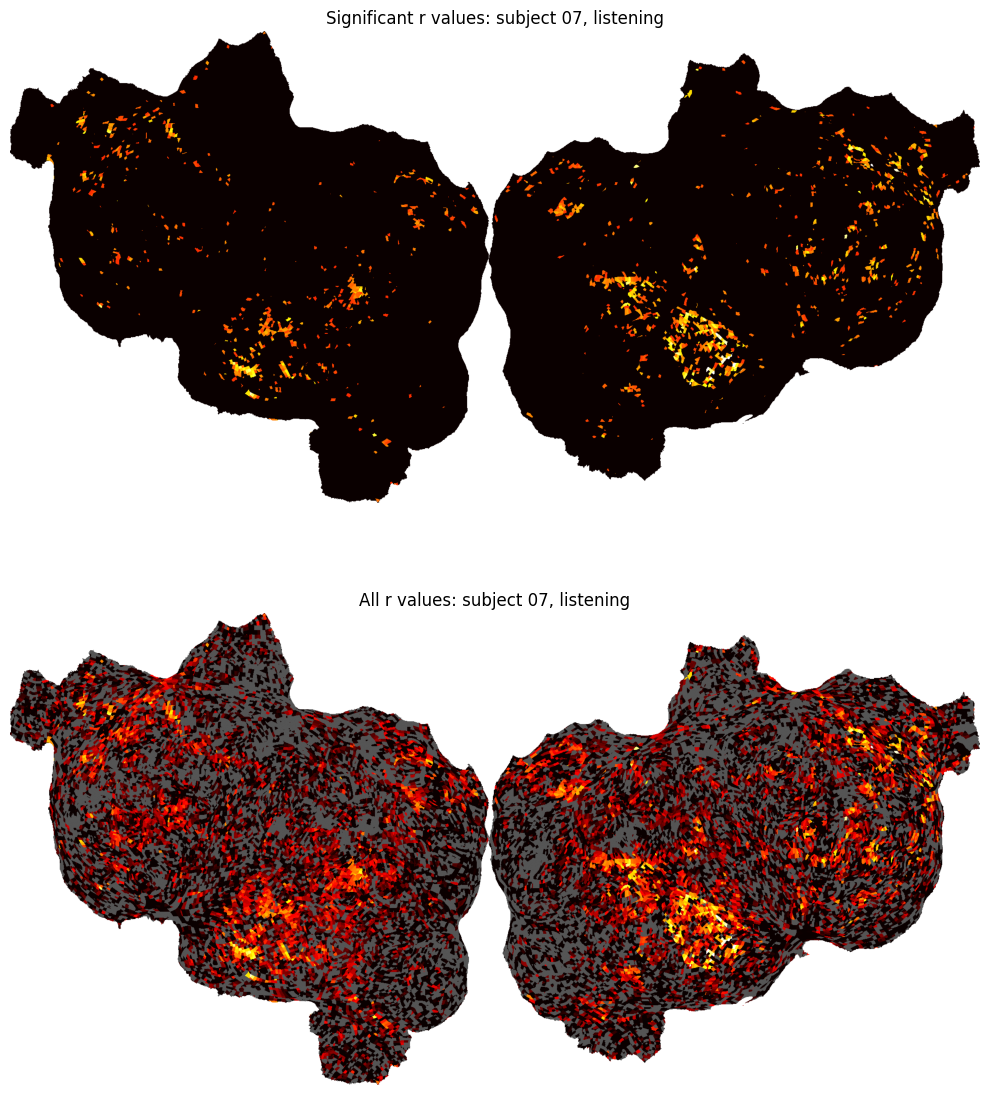

In [ ]:
# 11) Map to flatmap and save outputs
# for i in range(5):
#     # make volume data based on the surface and transform used to compute the score:
#     vol = cortex.Volume(r[i], "01", transform, cmap='inferno', vmin=0, vmax=0.5)
#     print(vol.shape)
# 
#     cortex.quickshow(vol, **plot_args)
#     plt.title('R for single word prediction')
#     plt.show()

cmap_ = plt.cm.hot 

# 2. Set the color for 'bad' (NaN/masked) values to Grey
cmap_.set_bad(color='white') 
cmap_.set_under(color='#555555')

map_file = os.path.join(fdir, "mappers", f"subject{subject}_mappers.hdf")
flatmap_sig = utils.map_to_flat(r_sig, map_file)
flatmap = utils.map_to_flat(r[0], map_file)
#flatmap = np.nan_to_num(flatmap)

os.makedirs("outputs", exist_ok=True)
np.save("outputs/subject{}_{}_r.npy".format(subject, modality), r)
np.save("outputs/subject{}_{}_flatmap.npy".format(subject, modality), flatmap)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Plot significant r values
axes[0].imshow(flatmap_sig, cmap=cmap_, vmin=0, vmax=0.4)
axes[0].axis("off")
axes[0].set_title(f"Significant r values: subject {subject}, {modality}")

# Plot normal r values
axes[1].imshow(flatmap, cmap=cmap_, vmin=0, vmax=0.4)
axes[1].axis("off")
axes[1].set_title(f"All r values: subject {subject}, {modality}")

plt.tight_layout()
plt.savefig("outputs/subject{}_{}_flatmap.png".format(subject, modality), bbox_inches="tight", dpi=150)
plt.show()